In [15]:
# Run this cell first to install all required packages
!pip install datasets transformers torch scikit-learn matplotlib seaborn pandas numpy tqdm
!pip install tokenizers accelerate evaluate
!pip install shap lime captum  # for explainability
!pip install gradio  # for the dashboard UI


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



   ---------------------------------------- 0/2 [accelerate]
   ---------------------------------------- 0/2 [accelerate]
   ---------------------------------------- 0/2 [accelerate]
   -------------------- ------------------- 1/2 [evaluate]
   ---------------------------------------- 2/2 [evaluate]




[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: Invalid requirement: '#': Expected package name at the start of dependency specifier
    #
    ^

[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: Invalid requirement: '#': Expected package name at the start of dependency specifier
    #
    ^


In [10]:
!pip install datasets transformers torch scikit-learn pandas numpy matplotlib seaborn


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:
from datasets import load_dataset

In [12]:
dataset = load_dataset("google/code_x_glue_cc_defect_detection")

In [16]:
from datasets import load_dataset
import pandas as pd
import numpy as np

print("Loading CodeXGLUE Defect Detection dataset...")
dataset = load_dataset("google/code_x_glue_cc_defect_detection")
print("\nDataset loaded successfully!")
print(dataset)

Loading CodeXGLUE Defect Detection dataset...

Dataset loaded successfully!
DatasetDict({
    train: Dataset({
        features: ['id', 'func', 'target', 'project', 'commit_id'],
        num_rows: 21854
    })
    validation: Dataset({
        features: ['id', 'func', 'target', 'project', 'commit_id'],
        num_rows: 2732
    })
    test: Dataset({
        features: ['id', 'func', 'target', 'project', 'commit_id'],
        num_rows: 2732
    })
})


In [17]:
# Convert to pandas DataFrames for easier exploration
train_df = pd.DataFrame(dataset['train'])
valid_df = pd.DataFrame(dataset['validation'])
test_df  = pd.DataFrame(dataset['test'])

print(f"Train size:      {len(train_df):,} samples")
print(f"Validation size: {len(valid_df):,} samples")
print(f"Test size:       {len(test_df):,} samples")
print(f"\nColumns: {list(train_df.columns)}")

Train size:      21,854 samples
Validation size: 2,732 samples
Test size:       2,732 samples

Columns: ['id', 'func', 'target', 'project', 'commit_id']


In [18]:
# Look at the first few samples
print("=" * 80)
print("SAMPLE 1 — Label:", train_df['target'][0])
print("=" * 80)
print(train_df['func'][0][:1000])  # first 1000 chars
print("\n" + "=" * 80)
print("SAMPLE 2 — Label:", train_df['target'][1])
print("=" * 80)
print(train_df['func'][1][:1000])

SAMPLE 1 — Label: False
static av_cold int vdadec_init(AVCodecContext *avctx)

{

    VDADecoderContext *ctx = avctx->priv_data;

    struct vda_context *vda_ctx = &ctx->vda_ctx;

    OSStatus status;

    int ret;



    ctx->h264_initialized = 0;



    /* init pix_fmts of codec */

    if (!ff_h264_vda_decoder.pix_fmts) {

        if (kCFCoreFoundationVersionNumber < kCFCoreFoundationVersionNumber10_7)

            ff_h264_vda_decoder.pix_fmts = vda_pixfmts_prior_10_7;

        else

            ff_h264_vda_decoder.pix_fmts = vda_pixfmts;

    }



    /* init vda */

    memset(vda_ctx, 0, sizeof(struct vda_context));

    vda_ctx->width = avctx->width;

    vda_ctx->height = avctx->height;

    vda_ctx->format = 'avc1';

    vda_ctx->use_sync_decoding = 1;

    vda_ctx->use_ref_buffer = 1;

    ctx->pix_fmt = avctx->get_format(avctx, avctx->codec->pix_fmts);

    switch (ctx->pix_fmt) {

    case AV_PIX_FMT_UYVY422:

        vda_ctx->cv_pix_fmt_type = '2vuy';

        break;

    

In [19]:
# Label distribution
print("--- TRAIN LABEL DISTRIBUTION ---")
print(train_df['target'].value_counts())
print("\nLabel meanings:")
print("  0 = Clean code (no defect)")
print("  1 = Defective code (has bug/vulnerability)")

print("\n--- CLASS BALANCE ---")
counts = train_df['target'].value_counts()
total  = len(train_df)
print(f"  Defective (1): {counts[1]:,}  ({100*counts[1]/total:.1f}%)")
print(f"  Clean     (0): {counts[0]:,}  ({100*counts[0]/total:.1f}%)")

--- TRAIN LABEL DISTRIBUTION ---
target
False    11836
True     10018
Name: count, dtype: int64

Label meanings:
  0 = Clean code (no defect)
  1 = Defective code (has bug/vulnerability)

--- CLASS BALANCE ---
  Defective (1): 10,018  (45.8%)
  Clean     (0): 11,836  (54.2%)


C:\Users\DELL\AppData\Local\Temp\ipykernel_25220\3683890917.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"  Defective (1): {counts[1]:,}  ({100*counts[1]/total:.1f}%)")
C:\Users\DELL\AppData\Local\Temp\ipykernel_25220\3683890917.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"  Clean     (0): {counts[0]:,}  ({100*counts[0]/total:.1f}%)")


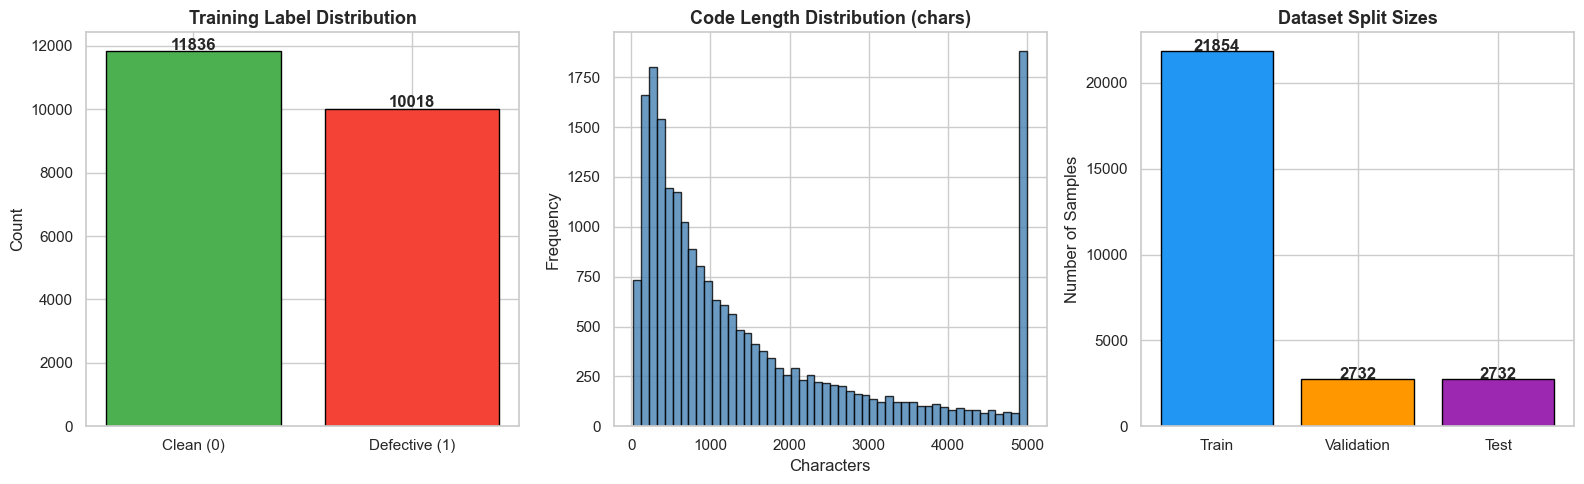

Plot saved as dataset_exploration.png


In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── Plot 1: Label distribution (train) ──
labels = ['Clean (0)', 'Defective (1)']
counts = train_df['target'].value_counts().sort_index()
axes[0].bar(labels, counts.values, color=['#4CAF50', '#F44336'], edgecolor='black')
axes[0].set_title('Training Label Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# ── Plot 2: Code length distribution ──
train_df['code_length'] = train_df['func'].apply(len)
axes[1].hist(train_df['code_length'].clip(upper=5000), bins=50,
             color='steelblue', edgecolor='black', alpha=0.8)
axes[1].set_title('Code Length Distribution (chars)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Characters')
axes[1].set_ylabel('Frequency')

# ── Plot 3: Split sizes ──
split_names  = ['Train', 'Validation', 'Test']
split_sizes  = [len(train_df), len(valid_df), len(test_df)]
axes[2].bar(split_names, split_sizes, color=['#2196F3','#FF9800','#9C27B0'], edgecolor='black')
axes[2].set_title('Dataset Split Sizes', fontsize=13, fontweight='bold')
axes[2].set_ylabel('Number of Samples')
for i, v in enumerate(split_sizes):
    axes[2].text(i, v + 30, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('dataset_exploration.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved as dataset_exploration.png")

In [21]:
# Code length stats per label
print("=== Code Length Statistics by Label ===")
print(train_df.groupby('target')['code_length'].describe().round(2))

=== Code Length Statistics by Label ===
          count     mean      std   min    25%     50%     75%       max
target                                                                  
False   11836.0  1909.98  4435.33  26.0  381.0   864.0  1984.0  142346.0
True    10018.0  2174.81  4739.01  31.0  440.0  1015.5  2380.0  134526.0


In [22]:
import os
os.makedirs('data', exist_ok=True)

train_df.to_csv('data/train_raw.csv', index=False)
valid_df.to_csv('data/valid_raw.csv', index=False)
test_df.to_csv('data/test_raw.csv',  index=False)

print("✅ Raw data saved to data/ folder")
print("   data/train_raw.csv")
print("   data/valid_raw.csv")
print("   data/test_raw.csv")

✅ Raw data saved to data/ folder
   data/train_raw.csv
   data/valid_raw.csv
   data/test_raw.csv
